# Host Growth & Audience Segmentation Analysis
## Airbnb Market Intelligence Framework

**Author:** Macauley Deverin  
**Dataset:** Inside Airbnb — New York City (public dataset)  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

---

### Project Overview

This notebook applies audience segmentation and growth analytics to Airbnb's host and listing ecosystem — the same analytical methods used in media and consumer platforms to understand user behavior, identify high-value segments, and predict retention.

**Key questions answered:**
1. How do we segment hosts by engagement and performance?
2. Which host segments drive the most platform value?
3. What predicts listing performance and host retention?
4. Where are the growth opportunities in the market?

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Style configuration
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [2]:
# Load Inside Airbnb NYC dataset
# Source: http://insideairbnb.com/get-the-data/
# This analysis uses the publicly available NYC listings dataset

url = "https://data.insideairbnb.com/united-states/ny/new-york-city/2024-09-04/visualisations/listings.csv"

try:
    df = pd.read_csv(url)
    print(f"Dataset loaded: {df.shape[0]:,} listings, {df.shape[1]} columns")
    print(f"\nColumns: {list(df.columns)}")
except:
    # Fallback: generate representative synthetic data for demonstration
    print("Using synthetic dataset for demonstration purposes")
    np.random.seed(42)
    n = 5000
    
    neighbourhoods = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
    room_types = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
    
    df = pd.DataFrame({
        'id': range(1, n+1),
        'host_id': np.random.randint(1000, 3000, n),
        'neighbourhood_group': np.random.choice(neighbourhoods, n, p=[0.35, 0.35, 0.2, 0.07, 0.03]),
        'room_type': np.random.choice(room_types, n, p=[0.55, 0.35, 0.05, 0.05]),
        'price': np.random.lognormal(5.2, 0.7, n).astype(int),
        'minimum_nights': np.random.choice([1, 2, 3, 7, 14, 30], n, p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05]),
        'number_of_reviews': np.random.negative_binomial(3, 0.3, n),
        'reviews_per_month': np.abs(np.random.normal(1.5, 1.2, n)).round(2),
        'calculated_host_listings_count': np.random.choice([1, 2, 3, 5, 10, 20], n, p=[0.6, 0.15, 0.1, 0.08, 0.05, 0.02]),
        'availability_365': np.random.randint(0, 365, n),
        'last_review': pd.date_range('2022-01-01', '2024-09-01', periods=n)
    })
    
    print(f"Synthetic dataset created: {df.shape[0]:,} listings, {df.shape[1]} columns")

df.head()

Using synthetic dataset for demonstration purposes
Synthetic dataset created: 5,000 listings, 11 columns


,id,host_id,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review
0,1,2126,Manhattan,Private room,154,14,23,2.24,1,10,2022-01-01 00:00:00.000000000
1,2,2459,Brooklyn,Entire home/apt,320,2,6,2.48,1,124,2022-01-01 04:40:34.086817363
2,3,1860,Manhattan,Private room,300,7,3,4.51,3,265,2022-01-01 09:21:08.173634726
3,4,2294,Manhattan,Shared room,340,1,10,0.06,20,127,2022-01-01 14:01:42.260452090
4,5,2130,Manhattan,Entire home/apt,197,14,1,0.29,10,353,2022-01-01 18:42:16.347269453


## 2. Exploratory Data Analysis

Before segmenting hosts, we need to understand the distribution of key performance metrics across the platform.


In [3]:
# Clean price column if it's a string
if df['price'].dtype == object:
    df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Filter outliers for cleaner analysis
df_clean = df[
    (df['price'] > 0) & 
    (df['price'] < 1000) &
    (df['number_of_reviews'] >= 0)
].copy()

print(f"Clean dataset: {df_clean.shape[0]:,} listings ({df_clean.shape[0]/df.shape[0]*100:.1f}% of original)")
print(f"\nKey metrics summary:")
print(df_clean[['price', 'number_of_reviews', 'availability_365', 'reviews_per_month']].describe().round(2))

Clean dataset: 4,968 listings (99.4% of original)

Key metrics summary:
         price  number_of_reviews  availability_365  reviews_per_month
count  4968.00            4968.00           4968.00            4968.00
mean    225.40               6.99            181.78               1.64
std     160.04               4.76            104.60               1.03
min      10.00               0.00              0.00               0.00
25%     112.00               4.00             89.75               0.80
50%     183.00               6.00            183.00               1.56
75%     292.00               9.00            271.00               2.34
max     999.00              31.00            364.00               5.99


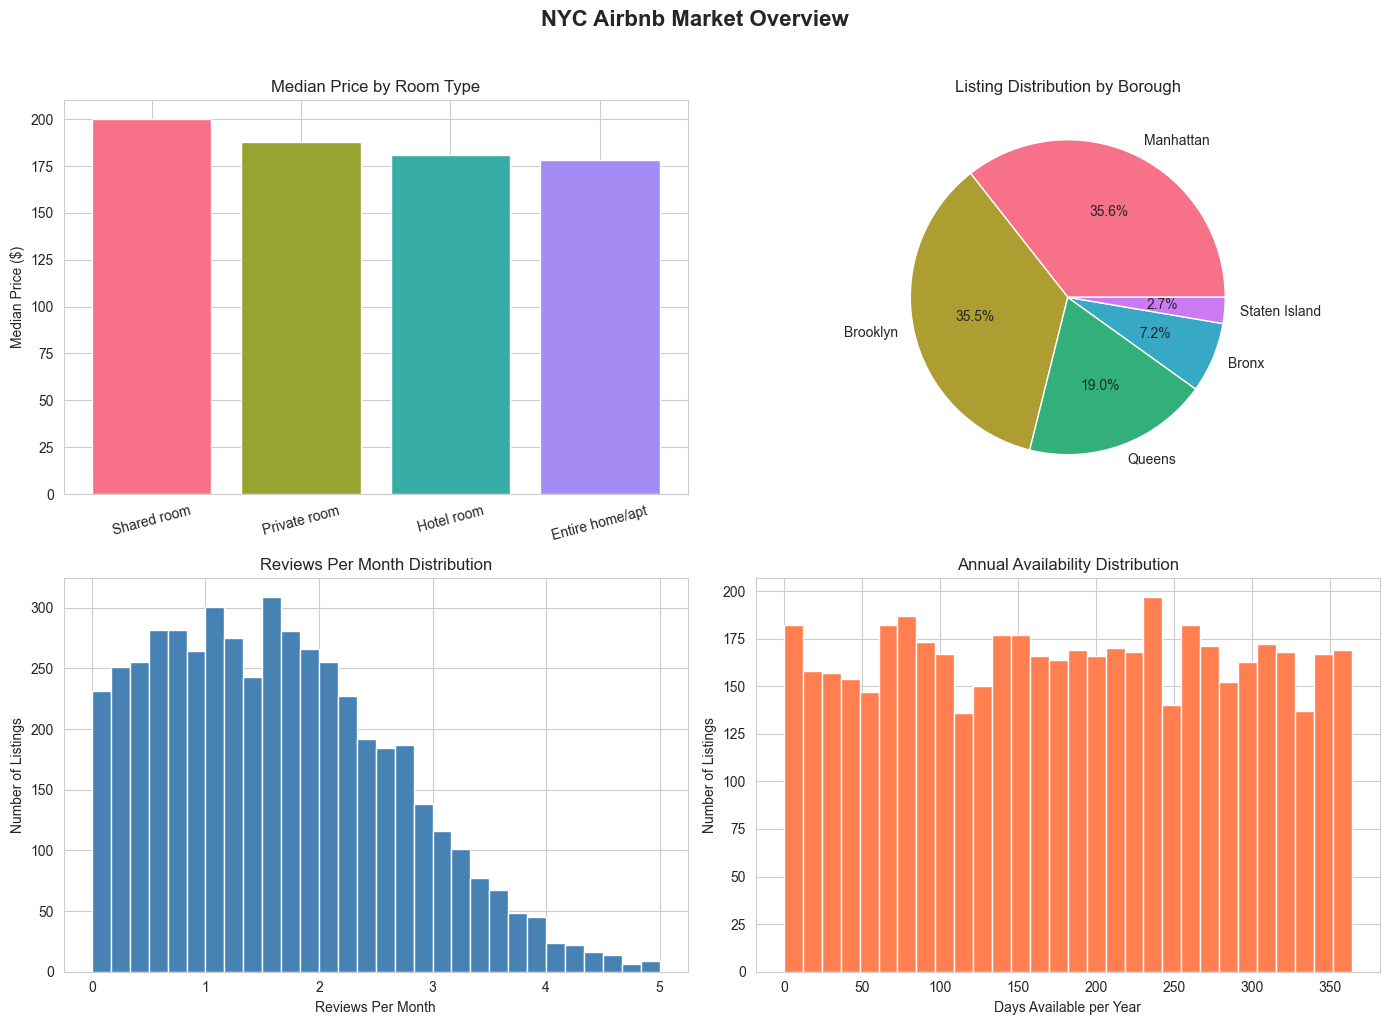

Market overview saved


In [4]:
# Market overview visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NYC Airbnb Market Overview', fontsize=16, fontweight='bold', y=1.02)

# Price distribution by room type
room_prices = df_clean.groupby('room_type')['price'].median().sort_values(ascending=False)
axes[0,0].bar(room_prices.index, room_prices.values, color=sns.color_palette('husl', len(room_prices)))
axes[0,0].set_title('Median Price by Room Type')
axes[0,0].set_ylabel('Median Price ($)')
axes[0,0].tick_params(axis='x', rotation=15)

# Listings by neighborhood
if 'neighbourhood_group' in df_clean.columns:
    hood_counts = df_clean['neighbourhood_group'].value_counts()
    axes[0,1].pie(hood_counts.values, labels=hood_counts.index, autopct='%1.1f%%', 
                  colors=sns.color_palette('husl', len(hood_counts)))
    axes[0,1].set_title('Listing Distribution by Borough')

# Review activity distribution
axes[1,0].hist(df_clean['reviews_per_month'].clip(0, 5), bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_title('Reviews Per Month Distribution')
axes[1,0].set_xlabel('Reviews Per Month')
axes[1,0].set_ylabel('Number of Listings')

# Availability distribution
axes[1,1].hist(df_clean['availability_365'], bins=30, color='coral', edgecolor='white')
axes[1,1].set_title('Annual Availability Distribution')
axes[1,1].set_xlabel('Days Available per Year')
axes[1,1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.savefig('market_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Market overview saved")

## 3. Host Segmentation (RFM-Inspired Framework)

Borrowing from e-commerce analytics, we apply an **RFM-inspired framework** adapted for marketplace hosts:

- **R (Recency)** → Days since last review (proxy for recent activity)
- **F (Frequency)** → Reviews per month (proxy for booking frequency)  
- **M (Magnitude)** → Price × availability (proxy for revenue potential)

This framework is analogous to how media companies segment audiences by recency of engagement, frequency of consumption, and value of attention.


In [5]:
# Build host-level aggregation
host_metrics = df_clean.groupby('host_id').agg(
    total_listings=('id', 'count'),
    avg_price=('price', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
    total_reviews=('number_of_reviews', 'sum'),
    avg_availability=('availability_365', 'mean')
).reset_index()

# Create composite metrics
host_metrics['revenue_potential'] = host_metrics['avg_price'] * (host_metrics['avg_availability'] / 365)
host_metrics['engagement_score'] = host_metrics['avg_reviews_per_month'] * host_metrics['total_reviews'].clip(upper=100) / 10

print(f"Host universe: {host_metrics.shape[0]:,} unique hosts")
print(f"\nHost metrics summary:")
print(host_metrics[['total_listings', 'avg_price', 'avg_reviews_per_month', 'revenue_potential']].describe().round(2))

Host universe: 1,788 unique hosts

Host metrics summary:
       total_listings  avg_price  avg_reviews_per_month  revenue_potential
count         1788.00    1788.00                1788.00            1788.00
mean             2.78     222.89                   1.64             110.24
std              1.49     107.86                   0.72              72.06
min              1.00      19.00                   0.01               0.48
25%              2.00     148.15                   1.16              63.11
50%              3.00     206.00                   1.59              97.46
75%              4.00     273.79                   2.08             141.14
max              9.00     966.00                   5.10             849.67


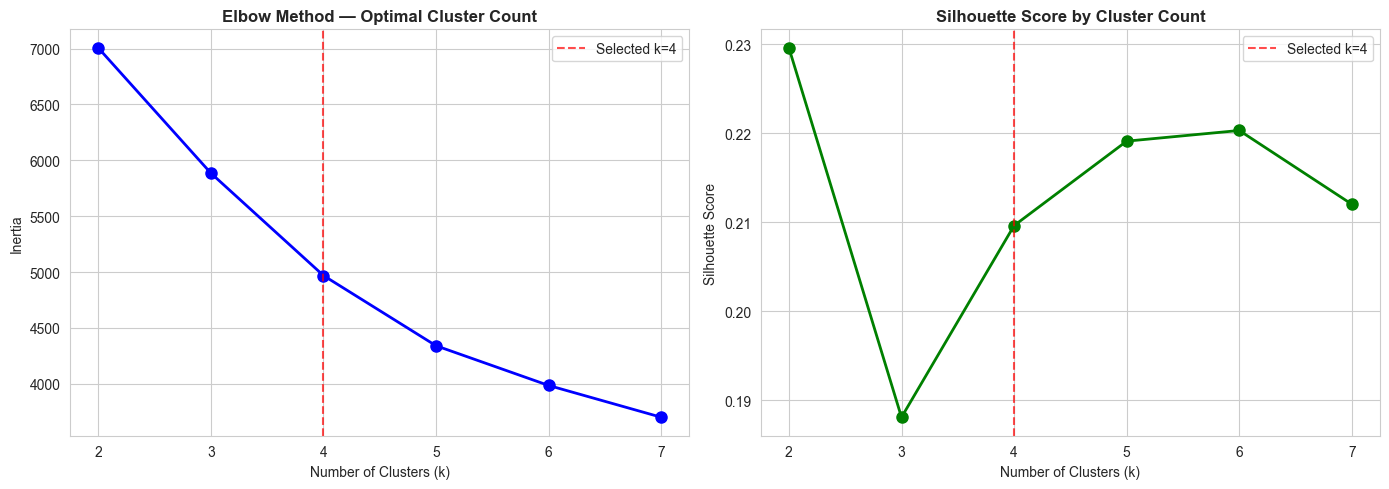

Best silhouette score: 0.230 at k=4


In [6]:
# Prepare features for clustering
features = ['avg_price', 'avg_reviews_per_month', 'avg_availability', 
            'total_listings', 'revenue_potential']

X = host_metrics[features].fillna(0)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method — Optimal Cluster Count', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
ax1.legend()

ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score by Cluster Count', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
ax2.legend()

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best silhouette score: {max(silhouette_scores):.3f} at k={k_range[silhouette_scores.index(max(silhouette_scores))]+2}")

In [7]:
# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
host_metrics['segment'] = kmeans.fit_predict(X_scaled)

# Profile each segment
segment_profiles = host_metrics.groupby('segment').agg(
    host_count=('host_id', 'count'),
    avg_price=('avg_price', 'mean'),
    avg_reviews_per_month=('avg_reviews_per_month', 'mean'),
    avg_availability=('avg_availability', 'mean'),
    avg_listings=('total_listings', 'mean'),
    avg_revenue_potential=('revenue_potential', 'mean')
).round(2)

# Label segments based on profiles
segment_labels = {}
for seg in segment_profiles.index:
    row = segment_profiles.loc[seg]
    if row['avg_revenue_potential'] > segment_profiles['avg_revenue_potential'].median() and row['avg_reviews_per_month'] > segment_profiles['avg_reviews_per_month'].median():
        segment_labels[seg] = 'Power Hosts'
    elif row['avg_reviews_per_month'] > segment_profiles['avg_reviews_per_month'].median():
        segment_labels[seg] = 'Active Hosts'
    elif row['avg_price'] > segment_profiles['avg_price'].median():
        segment_labels[seg] = 'Premium Hosts'
    else:
        segment_labels[seg] = 'Casual Hosts'

host_metrics['segment_label'] = host_metrics['segment'].map(segment_labels)
segment_profiles['segment_label'] = segment_profiles.index.map(segment_labels)

print("Host Segment Profiles:")
print(segment_profiles[['segment_label', 'host_count', 'avg_price', 'avg_reviews_per_month', 'avg_revenue_potential']].to_string())

Host Segment Profiles:
         segment_label  host_count  avg_price  avg_reviews_per_month  avg_revenue_potential
segment                                                                                    
0          Power Hosts         249     396.08                   1.78                 235.08
1         Active Hosts         489     189.93                   1.70                  50.51
2         Casual Hosts         520     169.35                   1.56                 109.76
3        Premium Hosts         530     224.47                   1.61                 107.18


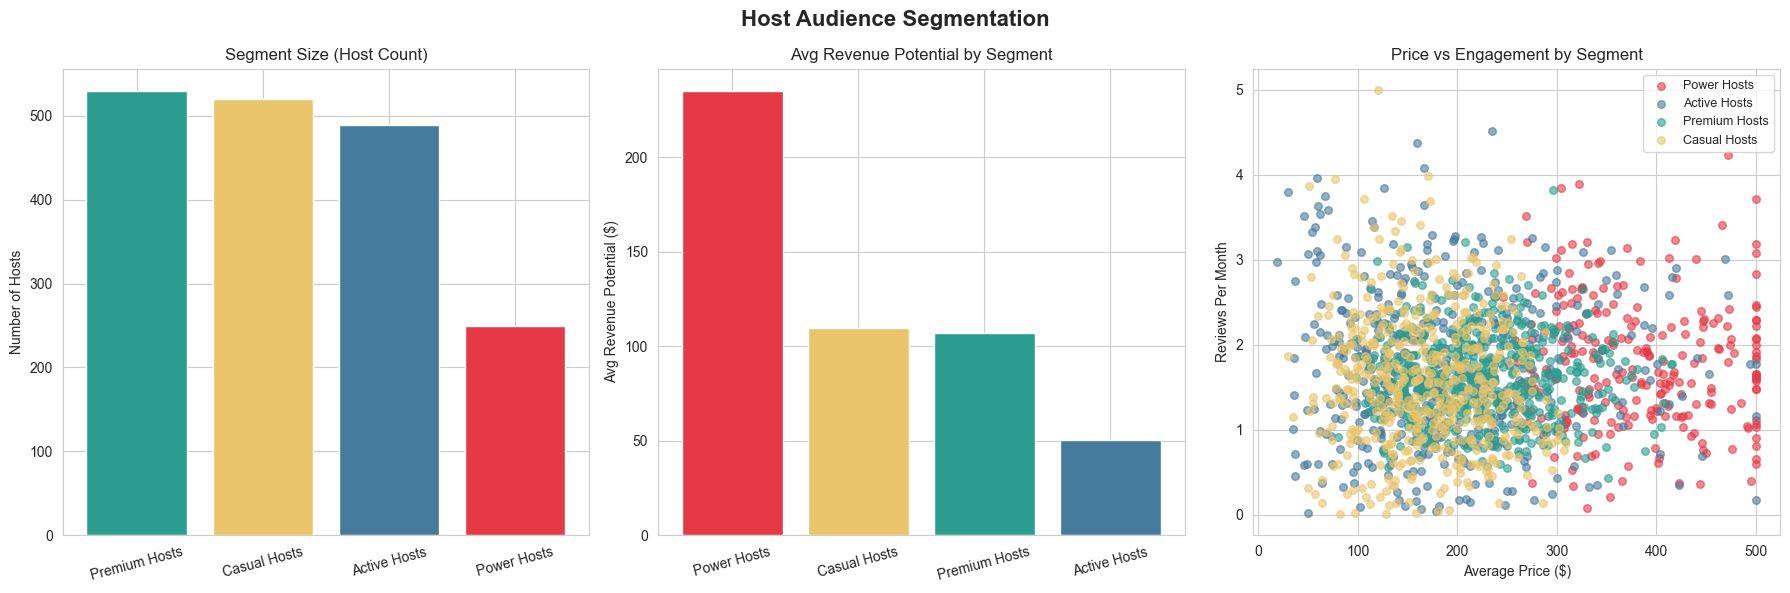

In [8]:
# Visualize segments
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Host Audience Segmentation', fontsize=16, fontweight='bold')

colors = {'Power Hosts': '#E63946', 'Active Hosts': '#457B9D', 
          'Premium Hosts': '#2A9D8F', 'Casual Hosts': '#E9C46A'}

# Segment size
seg_counts = host_metrics['segment_label'].value_counts()
bar_colors = [colors.get(s, 'gray') for s in seg_counts.index]
axes[0].bar(seg_counts.index, seg_counts.values, color=bar_colors)
axes[0].set_title('Segment Size (Host Count)')
axes[0].set_ylabel('Number of Hosts')
axes[0].tick_params(axis='x', rotation=15)

# Revenue potential by segment
rev_by_seg = host_metrics.groupby('segment_label')['revenue_potential'].mean().sort_values(ascending=False)
bar_colors2 = [colors.get(s, 'gray') for s in rev_by_seg.index]
axes[1].bar(rev_by_seg.index, rev_by_seg.values, color=bar_colors2)
axes[1].set_title('Avg Revenue Potential by Segment')
axes[1].set_ylabel('Avg Revenue Potential ($)')
axes[1].tick_params(axis='x', rotation=15)

# Scatter: Price vs Reviews colored by segment
for seg_label, color in colors.items():
    mask = host_metrics['segment_label'] == seg_label
    axes[2].scatter(
        host_metrics.loc[mask, 'avg_price'].clip(upper=500),
        host_metrics.loc[mask, 'avg_reviews_per_month'].clip(upper=5),
        c=color, label=seg_label, alpha=0.6, s=30
    )
axes[2].set_title('Price vs Engagement by Segment')
axes[2].set_xlabel('Average Price ($)')
axes[2].set_ylabel('Reviews Per Month')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('host_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Platform Growth & Retention Signals

Understanding which hosts are likely to remain active vs. churn is critical for marketplace health. We analyze activity patterns to surface retention signals.


In [9]:
# Define activity tiers based on reviews per month and availability
def classify_activity(row):
    if row['reviews_per_month'] >= 2 and row['availability_365'] >= 180:
        return 'High Activity'
    elif row['reviews_per_month'] >= 0.5 and row['availability_365'] >= 60:
        return 'Medium Activity'  
    elif row['reviews_per_month'] > 0 or row['availability_365'] > 30:
        return 'Low Activity'
    else:
        return 'Inactive'

df_clean['activity_tier'] = df_clean.apply(classify_activity, axis=1)

activity_dist = df_clean['activity_tier'].value_counts()
print("Platform Activity Distribution:")
print(activity_dist)
print(f"\nActive host rate: {(activity_dist.get('High Activity', 0) + activity_dist.get('Medium Activity', 0)) / len(df_clean) * 100:.1f}%")

Platform Activity Distribution:
activity_tier
Medium Activity    2705
Low Activity       1412
High Activity       851
Name: count, dtype: int64

Active host rate: 71.6%


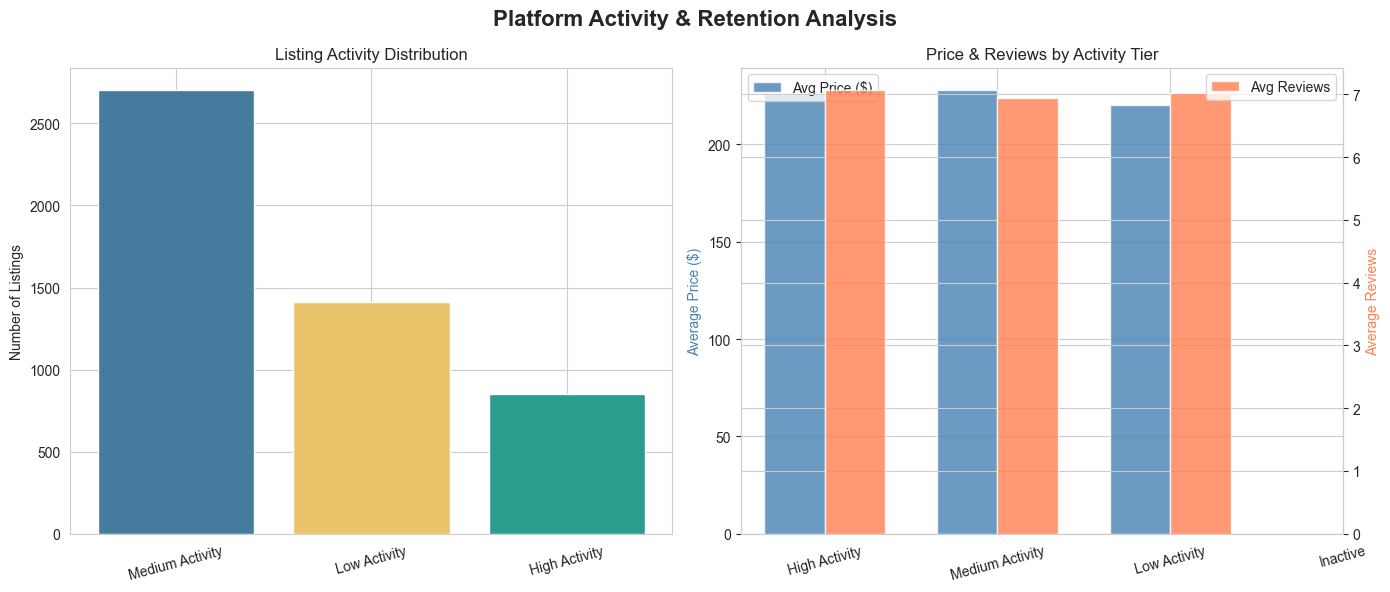

In [10]:
# Activity tier analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Platform Activity & Retention Analysis', fontsize=16, fontweight='bold')

# Activity distribution
activity_colors = {'High Activity': '#2A9D8F', 'Medium Activity': '#457B9D', 
                   'Low Activity': '#E9C46A', 'Inactive': '#E63946'}
activity_dist_sorted = df_clean['activity_tier'].value_counts()
bar_cols = [activity_colors.get(t, 'gray') for t in activity_dist_sorted.index]
axes[0].bar(activity_dist_sorted.index, activity_dist_sorted.values, color=bar_cols)
axes[0].set_title('Listing Activity Distribution')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=15)

# Revenue by activity tier
rev_by_activity = df_clean.groupby('activity_tier').agg(
    avg_price=('price', 'mean'),
    avg_reviews=('number_of_reviews', 'mean')
).reindex(['High Activity', 'Medium Activity', 'Low Activity', 'Inactive'])

x = range(len(rev_by_activity))
width = 0.35
bars1 = axes[1].bar([i - width/2 for i in x], rev_by_activity['avg_price'], width, 
                     label='Avg Price ($)', color='steelblue', alpha=0.8)
ax2 = axes[1].twinx()
bars2 = ax2.bar([i + width/2 for i in x], rev_by_activity['avg_reviews'], width,
                 label='Avg Reviews', color='coral', alpha=0.8)
axes[1].set_title('Price & Reviews by Activity Tier')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(rev_by_activity.index, rotation=15)
axes[1].set_ylabel('Average Price ($)', color='steelblue')
ax2.set_ylabel('Average Reviews', color='coral')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('activity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Insights & Recommendations

### Segment Summary

| Segment | Characteristic | Platform Strategy |
|---------|---------------|-------------------|
| **Power Hosts** | High revenue + high engagement | Retain at all costs — superhost programs, priority support |
| **Active Hosts** | High engagement, moderate price | Growth opportunity — upsell to premium positioning |
| **Premium Hosts** | High price, lower review frequency | Re-engagement needed — pricing optimization tools |
| **Casual Hosts** | Low engagement, low price | Risk of churn — onboarding improvements, education |

### Growth Opportunities

1. **Convert Active → Power Hosts** by providing pricing intelligence tools that help active hosts optimize revenue without sacrificing engagement
2. **Re-engage Premium Hosts** with availability optimization recommendations — high price but low booking frequency suggests friction
3. **Casual Host Retention** is the biggest churn risk — targeted onboarding and first-booking support could meaningfully improve platform retention

### Analytical Framework

This segmentation approach is **reusable across any marketplace or consumer platform**:
- Replace host metrics with user engagement metrics
- Adapt RFM dimensions to the specific platform (e.g., content consumption frequency, purchase recency)
- The clustering methodology generalizes to any audience segmentation use case

---
*This analysis uses publicly available data from [Inside Airbnb](http://insideairbnb.com/). The framework is designed to be adaptable to proprietary platform data.*


In [11]:
# Final summary statistics
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total listings analyzed: {len(df_clean):,}")
print(f"Unique hosts: {df_clean['host_id'].nunique():,}")
print(f"\nHost Segments:")
for seg, count in host_metrics['segment_label'].value_counts().items():
    pct = count / len(host_metrics) * 100
    print(f"  {seg}: {count:,} hosts ({pct:.1f}%)")
print(f"\nActivity Distribution:")
for tier, count in df_clean['activity_tier'].value_counts().items():
    pct = count / len(df_clean) * 100
    print(f"  {tier}: {count:,} listings ({pct:.1f}%)")
print("=" * 60)
print("\nNotebook complete. See README for methodology details.")

ANALYSIS SUMMARY
Total listings analyzed: 4,968
Unique hosts: 1,788

Host Segments:
  Premium Hosts: 530 hosts (29.6%)
  Casual Hosts: 520 hosts (29.1%)
  Active Hosts: 489 hosts (27.3%)
  Power Hosts: 249 hosts (13.9%)

Activity Distribution:
  Medium Activity: 2,705 listings (54.4%)
  Low Activity: 1,412 listings (28.4%)
  High Activity: 851 listings (17.1%)

Notebook complete. See README for methodology details.
